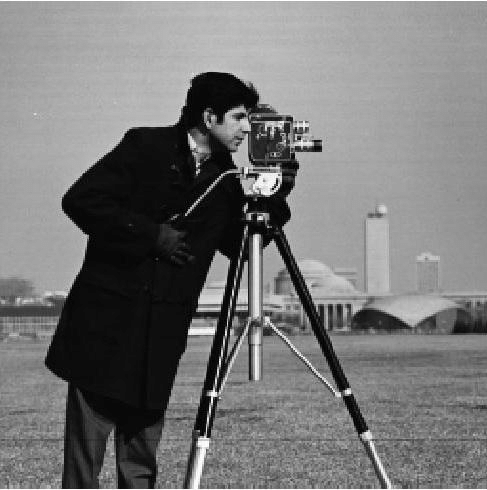

In [1]:
import sys
sys.path.append('../src')

from PIL import Image, ImageOps, ImageFont
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets
from ipywidgets import interactive, HBox, VBox, interact
from IPython.display import clear_output
from image.processing import preprocess_img, DITHER_MODES

IMG_PATH = "../imgs/cameraman.png"
orig_img = Image.open(IMG_PATH).convert("RGB")
display(orig_img)

In [2]:
def i_preprocess_img(
        scale_factor=0.5,
        contrast=1.0,
        brightness=1.0,
        sharpness=1.0,
        enhance_edges=0.0,
        quantize_colors=128,
        eq=0.0,
        dither=DITHER_MODES.NONE,
        grayscale=True):
    prep_img = preprocess_img(
        img=orig_img,
        scale_factor=scale_factor,
        contrast=contrast,
        brightness=brightness,
        eq=eq,
        quantize_colors=quantize_colors,
        dither=dither,
        sharpness=sharpness,
        enhance_edges=enhance_edges,
        grayscale=grayscale)
    
    plt.imshow(prep_img, cmap='gray', vmin=0, vmax=255, interpolation='none')
    plt.figure(figsize=(6, 3))
    plt.xticks([x for x in range(0, len(prep_img.histogram()), 50)])
    plt.bar([x for x in range(0, len(prep_img.histogram()))],
            prep_img.histogram())
    plt.grid()
    plt.show()
    return prep_img

interactive_preprocess = interactive(i_preprocess_img,
                                     scale_factor=(0.01, 1, 0.01),
                                     contrast=(0, 2, 0.01),
                                     brightness=(0, 2, 0.01),
                                     sharpness=(0, 2, 0.01),
                                     eq=(0, 1, 0.01),
                                     enhance_edges=(0, 1, 0.01),
                                     quantize_colors=(1, 256, 1),
                                     dither=DITHER_MODES,
                                     grayscale=True)

controls = VBox(interactive_preprocess.children[:-1])
display(HBox((controls, interactive_preprocess.children[-1])))

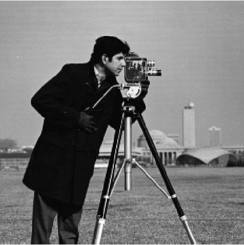

In [3]:
from converters.img_converter import ImgConverter
from converters.line_heuristics.line_converter import LineConverter
from converters.line_heuristics.utils import get_line_height
from palette.symbol2value import get_asciis, symbols_sorted
from rendering.image import render_symbols_img
from rendering.terminal import print_gallery

FONT_PATH = "../fonts/FiraCode-Regular.ttf"
FONT_SIZE = 16
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
SYMBOLS = symbols_sorted(get_asciis(), FONT)
MAX_WIDTH = 80
MAX_HEIGHT = 24

prep_img = interactive_preprocess.result
display(prep_img)



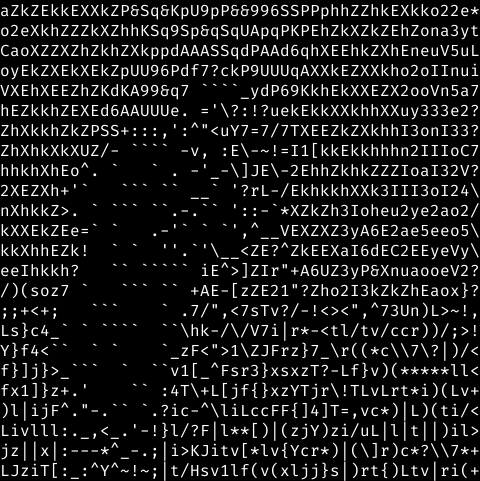

------------------------------------------------------
 | aZkZEkkEXXkZP&Sq&KpU9pP&&996SSPPphhZZhkEXkko22e* | 
 | o2eXkhZZZkXZhhKSq9Sp&qSqUApqPKPEhZkXZkZEhZona3yt | 
 | CaoXZZXZhZkhZXkppdAAASSqdPAAd6qhXEEhkZXhEneuV5uL | 
 | oyEkZXEkXEkZpUU96Pdf7?ckP9UUUqAXXkEZXXkho2oIInui | 
 | VXEhXEEZhZKdKA99&q7 ````_ydP69KkhEkXXEZX2ooVn5a7 | 
 | hEZkkhZEXEd6AAUUUe. ='\?:!?uekEkkXXkhhXXuy333e2? | 
 | ZhXkkhZkZPSS+:::,':^"<uY7=7/7TXEEZkZXkhhI3onI33? | 
 | ZhXhkXkXUZ/- ```` -v, :E\-~!=I1[kkEkkhhhn2IIIoC7 | 
 | hhkhXhEo^. `   ` . -'_-\]JE\-2EhhZkhkZZZIoaI32V? | 
 | 2XEZXh+'`   ``` `` __` '?rL-/EkhkkhXXk3III3oI24\ | 
 | nXhkkZ>. ` ``` ``.-.`` '::-`*XZkZh3Ioheu2ye2ao2/ | 
 | kXXEkZEe=` `   .-'` ` `',^__VEXZXZ3yA6E2ae5eeo5\ | 
 | kkXhhEZk!  ` `  ''.`'\__<ZE?^ZkEEXaI6dEC2EEyeVy\ | 
 | eeIhkkh?   `` ````` iE^>]ZIr"+A6UZ3yP&XnuaooeV2? | 
 | /)(soz7 `   ``` `` +AE-[zZE21"?Zho2I3kZkZhEaox}? | 
 | ;;+<+;   ```    ` .7/",<7sTv?/-!<><",^73Un)L>~!, | 
 | Ls}c4_` ` ````  ``\hk-/\/V7i|r*-<tl/tv/ccr))/;>! | 
 | Y}f4<``

In [4]:
from converters.tile.bin_1d import Tile2Symb1dBin
converter = LineConverter(tile_converter=Tile2Symb1dBin(symbols=SYMBOLS,
                                                        font=FONT,
                                                        bins=16))

res_arr = ImgConverter(converter).img2symbols(prep_img, max_cols=MAX_WIDTH, col_width=4, max_lines=MAX_HEIGHT, line_height=8)
display(render_symbols_img(res_arr, FONT))
print_gallery([res_arr], 1)

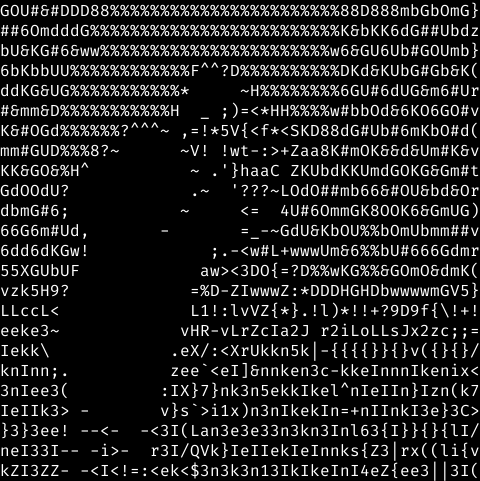

------------------------------------------------------
 | GOU#&#DDD88%%%%%%%%%%%%%%%%%%%%%%%88D888mbGbOmG} | 
 | ##6OmdddG%%%%%%%%%%%%%%%%%%%%%%%%%K&bKK6dG##Ubdz | 
 | bU&KG#6&ww%%%%%%%%%%%%%%%%%%%%%%%w6&GU6Ub#GOUmb} | 
 | 6bKbbUU%%%%%%%%%%%%F^^?D%%%%%%%%%%DKd&KUbG#Gb&K( | 
 | ddKG&UG%%%%%%%%%%%*     ~H%%%%%%%%6GU#6dUG&m6#Ur | 
 | #&mm&D%%%%%%%%%%%H  _ ;)=<*HH%%%%w#bbOd&6KO6GO#v | 
 | K&#OGd%%%%%%?^^^~ ,=!*5V{<f*<SKD88dG#Ub#6mKbO#d( | 
 | mm#GUD%%%8?~      ~V! !wt-:>+Zaa8K#mOK&&d&Um#K&v | 
 | KK&GO&%H^          ~ .'}haaC ZKUbdKKUmdGOKG&Gm#t | 
 | GdOOdU?            .~  '???~LOdO##mb66&#OU&bd&Or | 
 | dbmG#6;           ~     <=  4U#6OmmGK8OOK6&GmUG) | 
 | 66G6m#Ud,       -       =_-~GdU&KbOU%%bOmUbmm##v | 
 | 6dd6dKGw!            ;.-<w#L+wwwUm&6%%bU#666Gdmr | 
 | 55XGUbUF            aw><3DO{=?D%%wKG%%&GOmO&dmK( | 
 | vzk5H9?            =%D-ZIwwwZ:*DDDHGHDbwwwwmGV5} | 
 | LLccL<             L1!:lvVZ{*}.!l)*!!+?9D9f{\!+! | 
 | eeke3~            vHR-vLrZcIa2J r2iLoLLsJx2zc;;= | 
 | Iekk\  

In [5]:
from converters.tile.bin_2d import Tile2Symb2dBin
converter = LineConverter(tile_converter=Tile2Symb2dBin(symbols=SYMBOLS,
                                                        font=FONT))

res_arr = ImgConverter(converter).img2symbols(prep_img, max_cols=MAX_WIDTH, col_width=4, max_lines=MAX_HEIGHT, line_height=8)
display(render_symbols_img(res_arr, FONT))
print_gallery([res_arr], 1)

d:\CS Projects\python-playground\python-ascii-art\notebooks\../src\converters\tile\nearest.py:39: UserWarning: It is recommended to use mode = grid-constant instead of constant when grid_mode is True.
  tile = zoom(tile, zoom_factors, order=0, grid_mode=True)


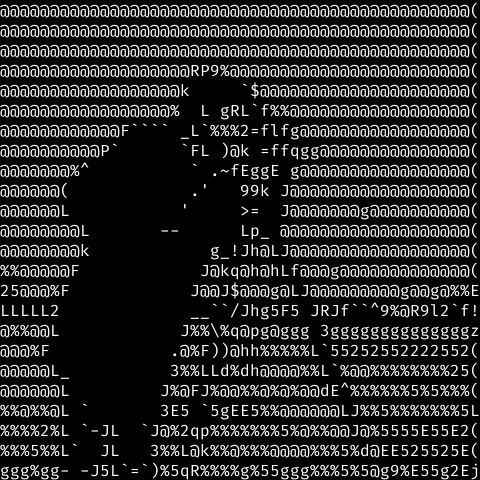

------------------------------------------------------
 | @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@@@@@@@@RP9%@@@@@@@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@@@@@@@k     `$@@@@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@@@@@@%  L gRL`f%%@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@F```` _L`%%%2=flfg@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@P`      `FL )@k =ffqgg@@@@@@@@@@@@@@@( | 
 | @@@@@@@%^          ` .~fEggE g@@@@@@@@@@@@@@@@@( | 
 | @@@@@@(            .'   99k J@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@L           '     >=  J@@@@@@@g@@@@@@@@@@( | 
 | @@@@@@@@L       --      Lp_ @@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@k            g_!Jh@LJ@@@@@@@@@@@@@@@@@@( | 
 | %%@@@@@F            J@kq@h@hLf@@@g@@@@@@@@@@@@@( | 
 | 25@@@%F            J@@J$@@@g@LJ@@@@@@@@@g@@g@%%E | 
 | LLLLL2             __``/Jhg5F5 JRJf``^9%@R9l2`f! | 
 | @%%@@L            J%%\%q@pg@ggg 3ggggggggggggggz | 
 | @@@%F  

In [6]:
from converters.tile.nearest import Tile2SymbNearest
converter = LineConverter(tile_converter=Tile2SymbNearest(symbols=SYMBOLS,
                                                          font=FONT))

res_arr = ImgConverter(converter).img2symbols(prep_img, max_cols=MAX_WIDTH, col_width=4, max_lines=MAX_HEIGHT, line_height=8)
display(render_symbols_img(res_arr, FONT))
print_gallery([res_arr], 1)

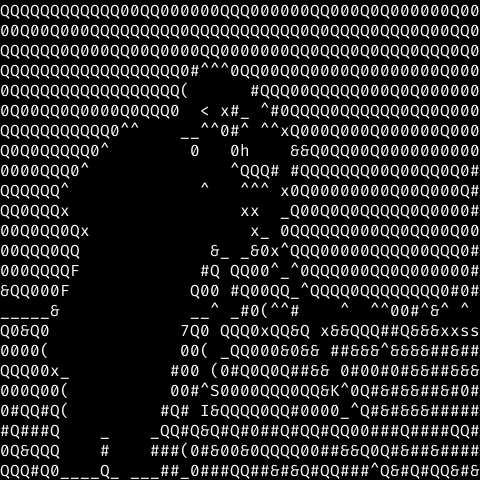

------------------------------------------------------
 | QQQQQQQQQQQQ00QQ000000QQQ000000QQ000Q0Q000000Q00 | 
 | 00Q00Q000QQQQQQQQQ0QQQQQQQQQQQ0Q0QQQQ0QQQ0Q00QQ0 | 
 | QQQQQQ0Q000QQ00Q0000QQ0000000QQ0QQQ0Q0QQQ0QQQ0Q0 | 
 | QQQQQQQQQQQQQQQQQQ0#^^^0QQ00Q0Q0000Q00000000Q000 | 
 | 0QQQQQQQQQQQQQQQQQ(      #QQQ00QQQQQ000Q0Q000000 | 
 | 0Q00QQ0Q0000Q0QQQ0  < x#_ ^#0QQQQ0QQQQQQ0QQ0Q000 | 
 | QQQQQQQQQQQ0^^    __^^0#^ ^^xQ000Q000Q000000Q000 | 
 | Q0Q0QQQQQ0^        0   0h    &&Q0QQ00Q0000000000 | 
 | 0000QQQ0^              ^QQQ# #QQQQQQQ00Q00QQ0Q0# | 
 | QQQQQQ^             ^   ^^^ x0Q00000000Q00Q000Q# | 
 | QQ0QQQx                 xx  _Q00Q0Q0QQQQQ0Q0000# | 
 | 00Q0QQ0Qx                x_ 0QQQQQQ000QQ0QQ00Q00 | 
 | 00QQQ0QQ             &_ _&0x^QQQ00000QQQQ00QQQ0# | 
 | 000QQQQF            #Q QQ00^_^0QQQ000QQ0Q000000# | 
 | &QQ000F            Q00 #Q00QQ_^QQQQ0QQQQQQQQ0#0# | 
 | _____&             __^ _#0(^^#    ^  ^^00#^&^ ^  | 
 | Q0&Q0             7Q0 QQQ0xQQ&Q x&&QQQ##Q&&&xxss | 
 | 0000(  

In [7]:
from converters.line_heuristics.greedy import GreedyLineSearch
converter = GreedyLineSearch(symbols=SYMBOLS[::5],
                             font=FONT)

res_arr = ImgConverter(converter).img2symbols(prep_img,
                                              max_cols=MAX_WIDTH,
                                              max_lines=MAX_HEIGHT, 
                                              line_height=get_line_height(SYMBOLS, FONT))
display(render_symbols_img(res_arr, FONT))
print_gallery([res_arr], 1)

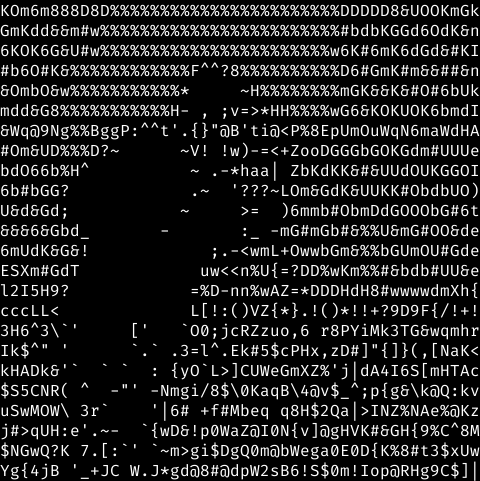

------------------------------------------------------
 | KOm6m888D8D%%%%%%%%%%%%%%%%%%%%%%%DDDDD8&UOOKmGk | 
 | GmKdd&&m#w%%%%%%%%%%%%%%%%%%%%%%%%#bdbKGGd6OdK&n | 
 | 6KOK6G&U#w%%%%%%%%%%%%%%%%%%%%%%%w6K#6mK6dGd&#KI | 
 | #b6O#K&%%%%%%%%%%%%F^^?8%%%%%%%%%%D6#GmK#m&&##&n | 
 | &OmbO&w%%%%%%%%%%%*     ~H%%%%%%%%mGK&&K&#O#6bUk | 
 | mdd&G8%%%%%%%%%%%H- , ;v=>*HH%%%%wG6&KOKUOK6bmdI | 
 | &Wq@9Ng%%BggP:^^t'.{}"@B'ti@<P%8EpUmOuWqN6maWdHA | 
 | #Om&UD%%%D?~      ~V! !w)-=<+ZooDGGGbGOKGdm#UUUe | 
 | bdO66b%H^          ~ .-*haa| ZbKdKK&#&UUdOUKGGOI | 
 | 6b#bGG?            .~  '???~LOm&GdK&UUKK#ObdbUO) | 
 | U&d&Gd;           ~     >=  )6mmb#ObmDdGOOObG#6t | 
 | &&&6&Gbd_       -       :_ -mG#mGb#&%%U&mG#OO&de | 
 | 6mUdK&G&!            ;.-<wmL+OwwbGm&%%bGUmOU#Gde | 
 | ESXm#GdT            uw<<n%U{=?DD%wKm%%#&bdb#UU&e | 
 | l2I5H9?            =%D-nn%wAZ=*DDDHdH8#wwwwdmXh{ | 
 | cccLL<             L[!:()VZ{*}.!()*!!+?9D9F{/!+! | 
 | 3H6^3\`'     ['   `O0;jcRZzuo,6 r8PYiMk3TG&wqmhr | 
 | Ik$^" '

In [9]:
from converters.line_heuristics.harmony_search import HarmonyLineSearch
tile_converter = Tile2Symb2dBin(symbols=SYMBOLS, font=FONT)
converter = HarmonyLineSearch(symbols=SYMBOLS,
                              font=FONT,
                              pop_count=20,
                              generations=40,
                              tile_converter=tile_converter)

img_converter_gen = ImgConverter(converter).img2symbols_lazy(prep_img,
                                              max_cols=MAX_WIDTH,
                                              max_lines=MAX_HEIGHT, 
                                              line_height=get_line_height(SYMBOLS, FONT))

for res_arr in img_converter_gen:
    clear_output()
    display(render_symbols_img(res_arr, FONT))
    print_gallery([res_arr], 1)